# Outcome : 
<h2> to calucate  calories consumed by man
 

In [17]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from statsmodels.formula.api import ols 
from sklearn.tree import DecisionTreeRegressor 

In [3]:
df = pd.read_csv("calories_consumed.csv")
df.sample(4)

,Weight gained (grams),Calories Consumed
4,300,2500
9,1100,3900
7,62,1900
5,110,1600


# Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Weight gained (grams)  14 non-null     int64
 1   Calories Consumed      14 non-null     int64
dtypes: int64(2)
memory usage: 356.0 bytes


In [5]:
df.shape

(14, 2)

In [6]:
df.describe()

,Weight gained (grams),Calories Consumed
count,14.000000,14.000000
mean,357.714286,2340.714286
std,333.692495,752.109488
min,62.000000,1400.000000
25%,114.500000,1727.500000
50%,200.000000,2250.000000
75%,537.500000,2775.000000
max,1100.000000,3900.000000


In [7]:
df.corr()

,Weight gained (grams),Calories Consumed
Weight gained (grams),1.000000,0.946991
Calories Consumed,0.946991,1.000000


In [8]:
df.kurtosis()

Weight gained (grams)    0.431272
Calories Consumed       -0.290481
dtype: float64

In [9]:
df.isnull().mean()

Weight gained (grams)    0.0
Calories Consumed        0.0
dtype: float64

In [10]:
df.duplicated().sum()

0

# EDA

In [14]:
#colums sperations
num =['Weight gained (grams)','Calories Consumed']
cat=[]
time=[]

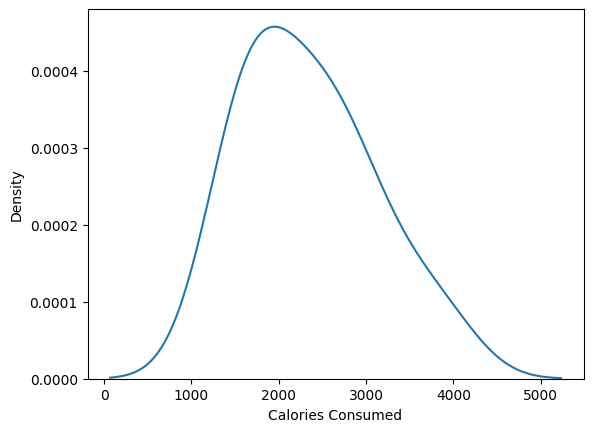

<module 'matplotlib.pyplot' from 'C:\\Users\\raj\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [25]:
# kde 
sns.kdeplot(df,x='Calories Consumed')
plt.show()

# already data is in normal distrbution and no need of 
plt

<Axes: xlabel='Calories Consumed', ylabel='Proportion'>

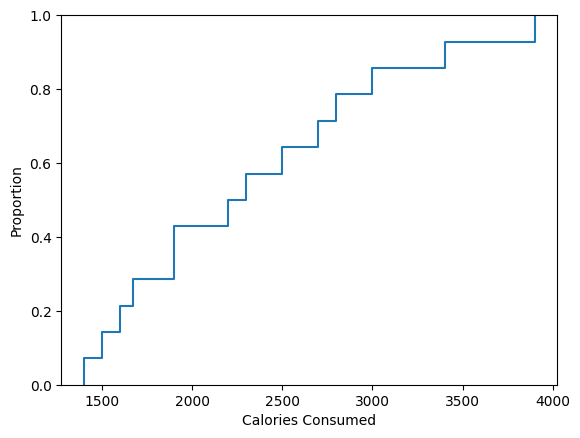

In [23]:
sns.ecdfplot(df,x='Calories Consumed')

<Axes: >

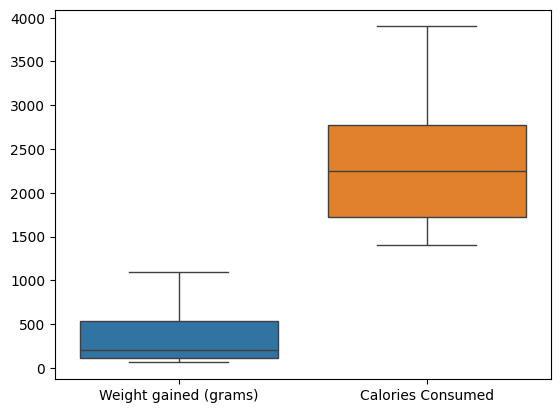

In [27]:
sns.boxplot(df)

<Axes: ylabel='Calories Consumed'>

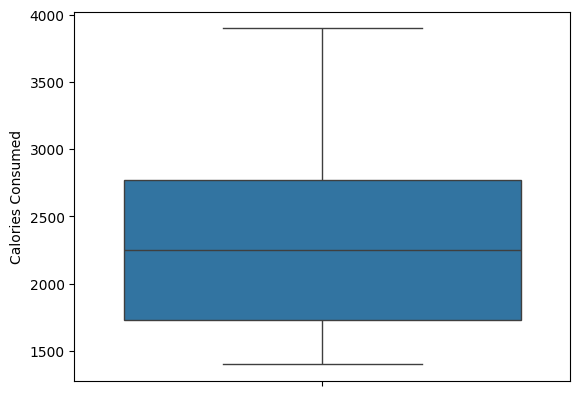

In [28]:
sns.boxplot(df['Calories Consumed'])

<Axes: ylabel='Weight gained (grams)'>

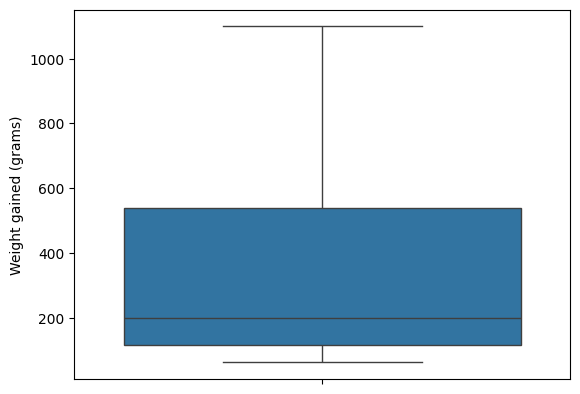

In [29]:
sns.boxplot(df['Weight gained (grams)'])

<Axes: xlabel='Weight gained (grams)', ylabel='Density'>

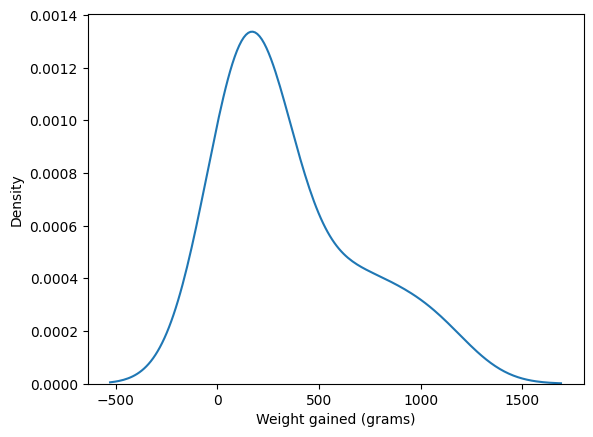

In [34]:
sns.kdeplot(df['Weight gained (grams)'])


In [58]:
k=np.random.normal(300,100,14)

<Axes: xlabel='Calories Consumed', ylabel='Weight gained (grams)'>

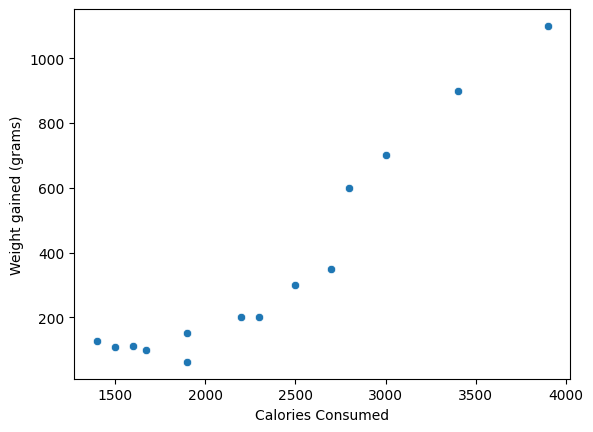

In [62]:
sns.scatterplot(df,x='Calories Consumed',y='Weight gained (grams)')

<Axes: >

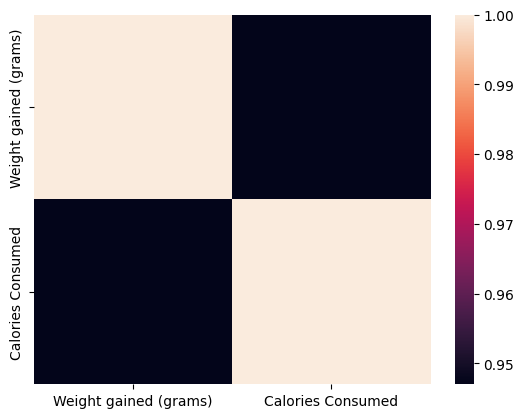

In [64]:
sns.heatmap(df.corr())

In [65]:
# correlated data 

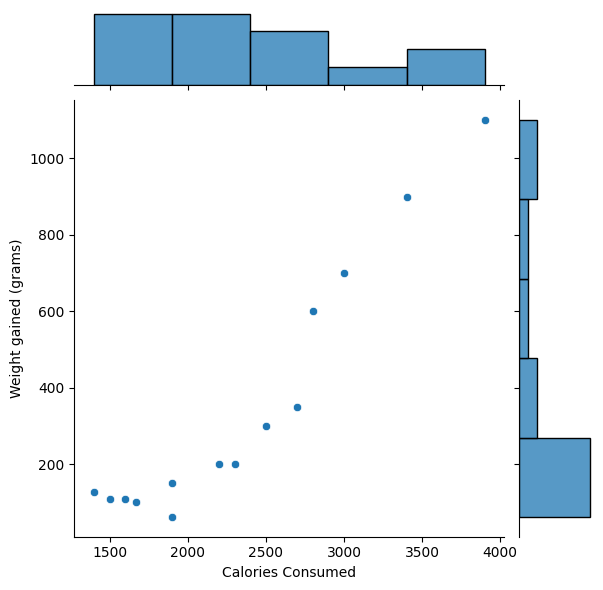

In [70]:
sns.jointplot(df,x='Calories Consumed',y='Weight gained (grams)')

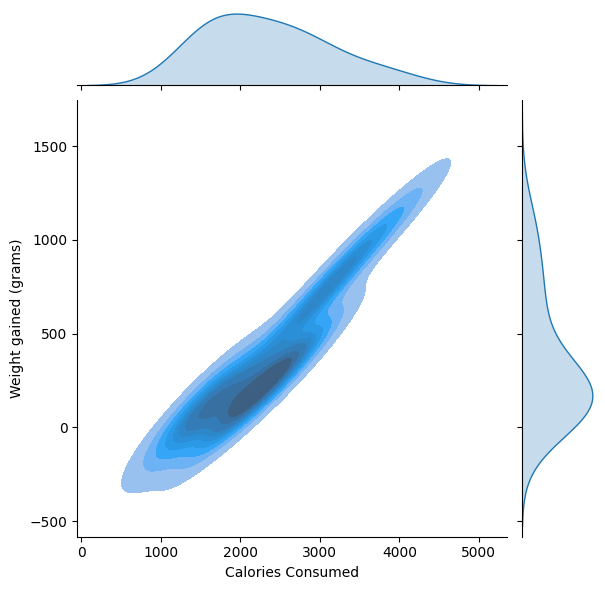

In [75]:
sns.jointplot(df,x='Calories Consumed',y='Weight gained (grams)',kind='kde',fill=True)

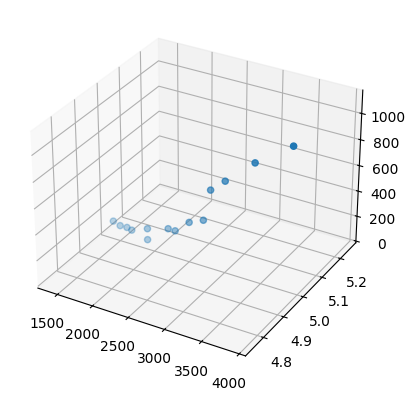

In [82]:
ax = plt.subplot(projection='3d')
ax.scatter(df['Calories Consumed'], 5,df['Weight gained (grams)'] )

In [84]:
# split the data 
lin = LinearRegression()
lin.fit(df[['Calories Consumed']],df[['Weight gained (grams)']])

LinearRegression()

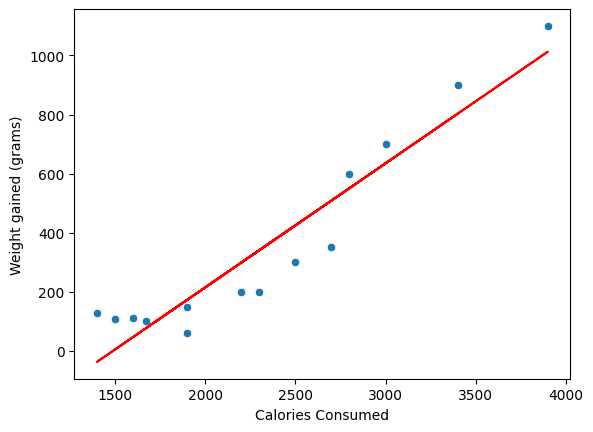

In [87]:
sns.scatterplot(df,x='Calories Consumed',y='Weight gained (grams)')
plt.plot(df['Calories Consumed'],lin.predict(df[['Calories Consumed']]),color='red')

In [89]:
reg2=DecisionTreeRegressor()
reg2.fit(df[['Calories Consumed']],df[['Weight gained (grams)']])

DecisionTreeRegressor()

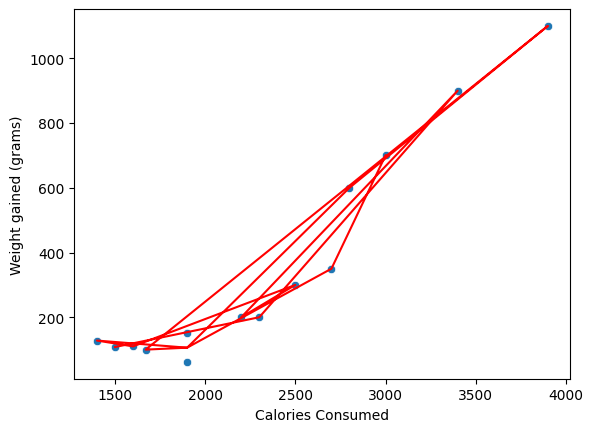

In [90]:
sns.scatterplot(df,x='Calories Consumed',y='Weight gained (grams)')
plt.plot(df['Calories Consumed'],reg2.predict(df[['Calories Consumed']]),color='red')

In [99]:
import statsmodels.formula.api as smf
model=smf.ols('y~X',data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     104.3
Date:                Wed, 26 Feb 2025   Prob (F-statistic):           2.86e-07
Time:                        22:43:56   Log-Likelihood:                -84.792
No. Observations:                  14   AIC:                             173.6
Df Residuals:                      12   BIC:                             174.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -625.7524    100.823     -6.206      0.0

C:\Users\raj\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=14
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [100]:
predict1=model.predict(pd.DataFrame(df.X))
predict1

0        4.482599
1      340.607908
2      802.780209
3      298.592245
4      424.639236
5       46.498263
6      -37.533065
7      172.545254
8      550.686227
9     1012.858527
10      75.909227
11     172.545254
12     508.670563
13     634.717554
dtype: float64

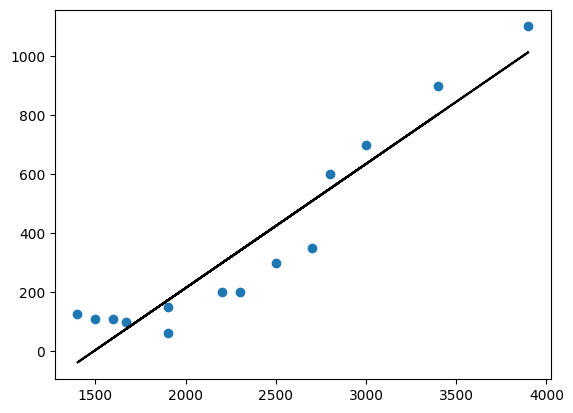

In [101]:
#regresion line 
plt.scatter(df[['X']],df.y)
plt.plot(df.X,predict1,'black')

In [110]:
from sklearn.preprocessing import PolynomialFeatures 
plt1=PolynomialFeatures(degree=2)

In [114]:
X_train =plt1.fit_transform(df[['X']])
y_train=plt1.fit_transform(df[['y']])

In [115]:
lin2=LinearRegression()
lin2.fit(X_train,y_train)

LinearRegression()

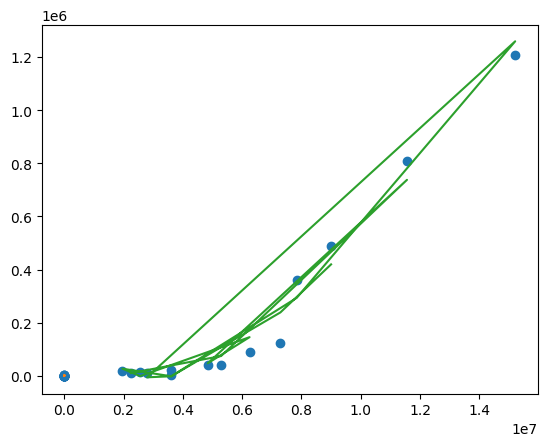

In [117]:
plt.scatter(X_train,y_train)
plt.plot(X_train,lin2.predict(X_train))

In [118]:
from sklearn.metrics import r2_score 
r2_score(y_train,lin2.predict(X_train))

0.9772313370388958